In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection     import train_test_split, StratifiedKFold
from sklearn.compose             import ColumnTransformer
from sklearn.preprocessing       import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute              import SimpleImputer
from sklearn.pipeline            import Pipeline
from tensorflow.keras            import Input, Sequential, Model
from tensorflow.keras.layers     import (
    Dense, Conv1D, Flatten, Dropout, BatchNormalization, Embedding,
    Concatenate, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [3]:
features = pd.read_csv('train_values.csv')
labels = pd.read_csv('train_labels.csv')

df = pd.concat([features, labels['damage_grade']], axis=1)
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [4]:
#Splitting the data between training and testing
X_train, X_val, y_train, y_val = train_test_split(df.drop('damage_grade', axis=1), df['damage_grade'], random_state=20, shuffle=True, test_size=0.01)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(257994, 39)
(2607, 39)
(257994,)
(2607,)


In [5]:
column_names = list(df.drop('damage_grade', axis=1).columns)
multi_class_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()>2]
binary_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()==2]
num_columns = [col for col in column_names if df[col].dtype!='object']
print(f"Multi Class columns: {multi_class_columns}")
print(f"Binary columns: {binary_columns}")
print(f"Numerical columns: {num_columns}")

Multi Class columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Binary columns: []
Numerical columns: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', '

In [6]:
numeric_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='median')),  # fill missing values
    ('scale',  StandardScaler())                   # standardize features
])

In [7]:

cat_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),  # fill missing with "MISSING"
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # one-hot encode
])


In [8]:
preprocessor_simple= ColumnTransformer([
    ('num', numeric_pipeline_simple, num_columns),
    ('cat', cat_pipeline_simple, multi_class_columns + binary_columns)
])

In [9]:
#build‐fn for a plain MLP
def build_ann_simple(input_dim, **kwargs):
    m = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(32,  activation='relu'),
        Dense(3,   activation='softmax'),
    ])
    m.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return m

In [10]:
# fit the preproc once to get feature_dim
X_tr_enc = preprocessor_simple.fit_transform(X_train)
feature_dim = X_tr_enc.shape[1]

In [12]:
from scikeras.wrappers import KerasClassifier
# wrap in SciKeras
ann_simple = KerasClassifier(
    build_fn=build_ann_simple,
    input_dim=feature_dim,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    callbacks=[
      EarlyStopping('val_loss', patience=3, restore_best_weights=True),
      ReduceLROnPlateau('val_loss', factor=0.5, patience=2)
    ],
    verbose=1
)

In [14]:
pipe_ann_simple = Pipeline([
    ('preproc', preprocessor_simple),
    ('clf',     ann_simple)
])

In [15]:
from sklearn.svm import LinearSVC
# Create an SVM classifier
pipe_ann_simple.fit(X_train, y_train)

/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
2025-04-27 06:17:04.055803: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
807/807 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5886 - loss: 0.8144 - val_accuracy: 0.6266 - val_loss: 0.7544 - learning_rate: 0.0010
Epoch 2/20
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6329 - loss: 0.7509 - val_accuracy: 0.6504 - val_loss: 0.7305 - learning_rate: 0.0010
Epoch 3/20
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6543 - loss: 0.7225 - val_accuracy: 0.6614 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 4/20
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6652 - loss: 0.7067 - val_accuracy: 0.6664 - val_loss: 0.7041 - learning_rate: 0.0010
Epoch 5/20
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6708 - loss: 0.7006 - val_accuracy: 0.6679 - val_loss: 0.7010 - learning_rate: 0.0010
Epoch 6/20
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6738 - loss: 0.6925 - val_accuracy: 0.6742 - val_loss: 0.6981 - learning_rate: 0.0010
Epoch 7/20
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6757 - loss: 0.6877 - 

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'geo_level_2_id',
                                                   'geo_level_3_id',
                                                   'count_floors_pre_eq', 'age',
                                                   'area_percentage',
                                                   'height_percentage',
                                                   'has_superstructure_adobe_mud',
                                                   'has_superstructure_mud_mortar_s...
                                                   'plan_configuration',
                                                   'legal_ownership_status'])])),
                ('clf',
                 KerasClassifier(batch_size=256, build_fn=<function build_ann_simple at 0x14df9c9beca0>, callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x14df9dbdd750>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x14df9db6ab10>], epochs=20, input_dim=69, validation_split=0.2))])

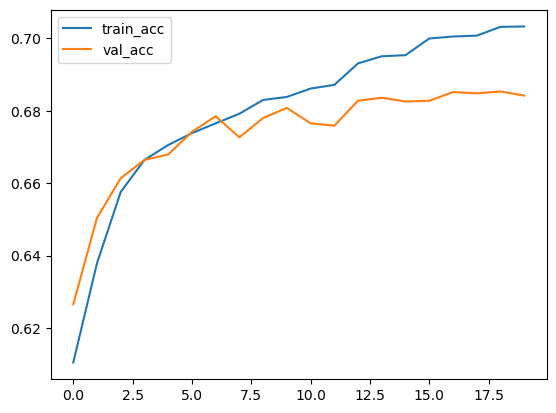

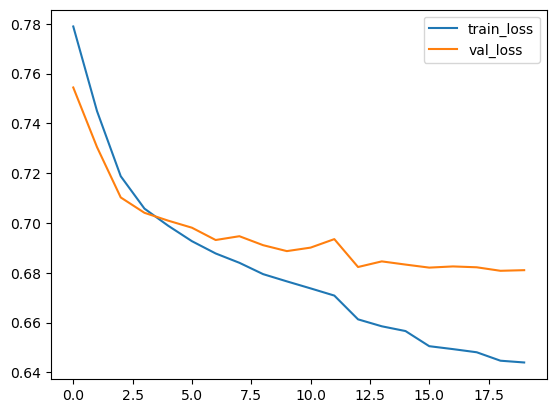

In [16]:
# plot
h = pipe_ann_simple.named_steps['clf'].history_
plt.plot(h['accuracy'], label='train_acc')
plt.plot(h['val_accuracy'], label='val_acc'); plt.legend(); plt.show()
plt.plot(h['loss'], label='train_loss')
plt.plot(h['val_loss'], label='val_loss'); plt.legend(); plt.show()


In [17]:
# Predict on validation set
y_pred = pipe_ann_simple.predict(X_val)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy on validation set: 0.6839278864595321

Classification Report:
               precision    recall  f1-score   support

           1       0.65      0.47      0.54       246
           2       0.69      0.80      0.75      1490
           3       0.67      0.54      0.60       871

    accuracy                           0.68      2607
   macro avg       0.67      0.60      0.63      2607
weighted avg       0.68      0.68      0.68      2607



In [18]:
df_test = pd.read_csv('test_values.csv')

In [19]:
ids     = df_test['building_id'].values
ids

array([ 300051,   99355,  890251, ..., 1049160,  442785,  501372])

In [20]:
X_test  = df_test

In [21]:
preds = pipe_ann_simple.predict(X_test)
pd.DataFrame({'building_id': ids, 'damage_grade': preds})\
  .to_csv('ANN_simple_submission.csv', index=False)

340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step


*** Preprocessed CNN****

In [22]:
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    # get the cutoffs once
    qs = X[['area_percentage','height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    
    # clip each column
    for col in ['area_percentage','height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

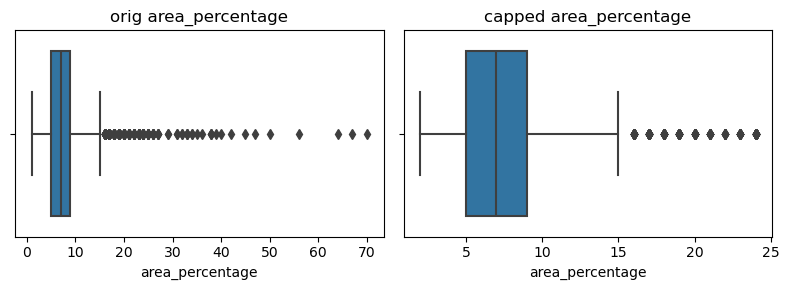

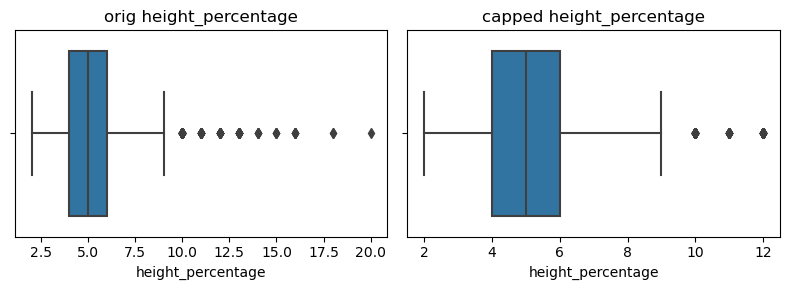

In [23]:
# apply to a small sample
sample = df[['area_percentage','height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)

import matplotlib.pyplot as plt, seaborn as sns

for col in ['area_percentage','height_percentage']:
    fig, axes = plt.subplots(1,2, figsize=(8,3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"orig {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"capped {col}")
    plt.tight_layout()
    plt.show()


In [25]:
from sklearn.base import BaseEstimator, TransformerMixin
# 1) Define our custom capper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols            # e.g. ['area_percentage','height_percentage']
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # X is a numpy array of shape (n_samples, n_num_cols)
        # find each target col’s integer index
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        # extract the sub‐array of just those columns
        sub = X[:, self.col_indices_]
        # compute quantiles along axis=0 → shape (2, len(cols))
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        # clip each specified column by its learned lo_/hi_
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

In [28]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler

# 2) Numeric pipeline
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('cap',    OutlierCapper(cols=['area_percentage','height_percentage'],
                             lower=0.01, upper=0.99)),
    ('power',  PowerTransformer(method='yeo-johnson')),
    ('scale',  RobustScaler()),
])


In [29]:
# 3) Categorical pipeline
cat_pipeline = Pipeline([
    # 3a) Impute missing categories into a "MISSING" bucket
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),
    # 3b) One-hot encode all levels, ignore unseen at predict time
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [33]:
# 4) Assemble ColumnTransformer
preprocessor_complex = ColumnTransformer([
    # apply numeric_pipeline to all numeric features
    ('num', numeric_pipeline, num_columns),
    # apply cat_pipeline to all categorical features
    ('cat', cat_pipeline,   multi_class_columns + binary_columns),
])


In [34]:
# reuse build_ann_simple and feature_dim
X_tr_enc2 = preprocessor_complex.fit_transform(X_train)
fd2 = X_tr_enc2.shape[1]

In [35]:
# # 5) Pipeline factory
# def get_pipeline(model):
#     """
#     Returns a full Pipeline that:
#      - applies preprocessor to DataFrame
#      - then fits the model
#     """
#     return Pipeline([
#         ('preprocessor', preprocessor),
#         ('clf',        model)
#     ])

In [36]:
# # 7) Quick Stratified 3-fold CV to compare
# cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# scoring = {
#     'acc':  'accuracy',
#     'f1':   'f1',       # or 'f1_weighted', depending on your class balance
#     'prec': 'precision',
#     'rec':  'recall'
# }

In [38]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import clone

ann_complex = KerasClassifier(
    build_fn=build_ann_simple,
    input_dim=fd2,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[
      EarlyStopping('val_loss', patience=5, restore_best_weights=True),
      ReduceLROnPlateau('val_loss', factor=0.3, patience=3)
    ],
    verbose=1
)

pipe_ann_complex = Pipeline([
    ('preproc', preprocessor_complex),
    ('clf',     ann_complex)
])
pipe_ann_complex.fit(X_train, y_train)

Epoch 1/30


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


1613/1613 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6022 - loss: 0.7931 - val_accuracy: 0.6307 - val_loss: 0.7515 - learning_rate: 0.0010
Epoch 2/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6357 - loss: 0.7470 - val_accuracy: 0.6488 - val_loss: 0.7345 - learning_rate: 0.0010
Epoch 3/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6560 - loss: 0.7246 - val_accuracy: 0.6690 - val_loss: 0.7078 - learning_rate: 0.0010
Epoch 4/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6678 - loss: 0.7063 - val_accuracy: 0.6709 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 5/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6737 - loss: 0.6955 - val_accuracy: 0.6716 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 6/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6749 - loss: 0.6918 - val_accuracy: 0.6755 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 7/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6791 - loss: 0.6845

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('cap',
                                                                   OutlierCapper(cols=['area_percentage',
                                                                                       'height_percentage'])),
                                                                  ('power',
                                                                   PowerTransformer()),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'geo_level_2_id',
                                                   'geo_level_3_id',
                                                   'count_floors_pre_eq', 'age',
                                                   'area_...
                                                   'plan_configuration',
                                                   'legal_ownership_status'])])),
                ('clf',
                 KerasClassifier(batch_size=128, build_fn=<function build_ann_simple at 0x14df9c9beca0>, callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x14df95556790>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x14df953565d0>], epochs=30, input_dim=69, validation_split=0.2))])

In [39]:
# 4) Predict on validation set
y_pred =pipe_ann_complex.predict(X_val)

# 5) Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy on validation set: 0.6835443037974683

Classification Report:
               precision    recall  f1-score   support

           1       0.63      0.42      0.51       246
           2       0.69      0.82      0.75      1490
           3       0.67      0.53      0.59       871

    accuracy                           0.68      2607
   macro avg       0.67      0.59      0.62      2607
weighted avg       0.68      0.68      0.67      2607



In [40]:
preds = pipe_ann_complex.predict(X_test)
# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,          # make sure you have 'ids' variable defined
    'damage_grade': preds
}).to_csv('ANN_complex_submission.csv', index=False)

679/679 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step


**Hyperparameter Tuning**

In [44]:
from keras_tuner import HyperModel, RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters
y_train = y_train - 1
y_val = y_val - 1
class ANNHyper(HyperModel):
    def build(self, hp):
        m = Sequential([Input(shape=(feature_dim,))])
        for i in range(hp.Int('n_layers', 1, 3)):
            units = hp.Int(f'units_{i}', 32, 256, step=32)
            m.add(Dense(units, activation='relu'))
            if hp.Boolean(f'use_bn_{i}'):
                m.add(BatchNormalization())
            m.add(Dropout(hp.Float(f'dropout_{i}', 0, 0.5, step=0.1)))
        m.add(Dense(3, activation='softmax'))
        m.compile(
            optimizer=Adam(hp.Float('lr', 1e-4, 1e-2, sampling='log')),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return m

# Now create tuner
tuner = RandomSearch(
    ANNHyper(),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='ann_tune',
    project_name='mlp2'
)

# Preprocessing
X_val_enc2 = preprocessor_complex.transform(X_val)

# Tuning
tuner.search(
    X_tr_enc2, y_train,
    validation_data=(X_val_enc2, y_val),
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)

# Best Model
best_ann = tuner.get_best_models(1)[0]


Trial 10 Complete [00h 03m 23s]
val_accuracy: 0.650556206703186

Best val_accuracy So Far: 0.6931338906288147
Total elapsed time: 00h 34m 43s


/home/sbaniya/.local/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [48]:

# transform your raw test DataFrame into the encoded numeric array
X_test_enc2 = preprocessor_complex.transform(X_test)

# 4) Generate predictions on your test set
pred_probs = best_ann.predict(X_test_enc2)

# 5) Take argmax
preds = np.argmax(pred_probs, axis=1)

# (Optional) Shift back to original label if needed
preds = preds + 1   # because you subtracted 1 before training

# 6) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,
    'damage_grade': preds
}).to_csv('ANN_tuned_submission.csv', index=False)


2715/2715 ━━━━━━━━━━━━━━━━━━━━ 3s 932us/step
